In [ ]:
# @title 1. Mount Google Drive & Setup
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# Create fresh data folder
save_dir = "/content/drive/MyDrive/RL_Maintenance_Project1/data"
if os.path.exists(save_dir):
    shutil.rmtree(save_dir)
os.makedirs(save_dir, exist_ok=True)
print(f"Data will be saved to: {save_dir}")

Mounted at /content/drive
Data will be saved to: /content/drive/MyDrive/RL_Maintenance_Project1/data


In [ ]:
# @title 2. Generate High‑Correlation Pure Synthetic Data
import numpy as np
import matplotlib.pyplot as plt

num_samples = 500_000
sampling_rate = 20480
duration = num_samples / sampling_rate
t = np.linspace(0, duration, num_samples)

# True degradation (0 → 1)
degradation = np.clip(t / duration, 0, 1)

# ---- Vibration: envelope = degradation, carrier = 100 Hz ----
# Envelope exactly equals degradation (range 0 to 1)
envelope = degradation.copy()
carrier = np.sin(2 * np.pi * 100 * t)
vibration = envelope * carrier + 0.02 * np.random.randn(num_samples)   # low noise

# ---- Temperature: linear with degradation, small daily cycle ----
temperature = 30 + 20 * degradation + 0.5 * np.sin(2 * np.pi * 0.5 * t)
temperature += 0.2 * np.random.randn(num_samples)   # low noise

# ---- Acoustic: proportional to envelope squared ----
acoustic = 0.5 * (envelope ** 2) + 0.05 * np.random.randn(num_samples)
acoustic = np.clip(acoustic, -0.5, 0.5)

print("High‑correlation synthetic data generated.")
print(f"Vibration range: [{vibration.min():.2f}, {vibration.max():.2f}]")
print(f"Temperature range: [{temperature.min():.1f}, {temperature.max():.1f}]")
print(f"Acoustic range: [{acoustic.min():.2f}, {acoustic.max():.2f}]")

High‑correlation synthetic data generated.
Vibration range: [-1.05, 1.04]
Temperature range: [29.5, 51.1]
Acoustic range: [-0.21, 0.50]


In [ ]:
# @title 3. Save Full Dataset to Drive
np.savez_compressed(
    os.path.join(save_dir, "pure_synthetic_data.npz"),
    vibration=vibration,
    temperature=temperature,
    acoustic=acoustic,
    degradation=degradation,
    time=t
)

# Also save a downsampled version (every 10th sample) for faster prototyping
vibration_ds = vibration[::10]
temperature_ds = temperature[::10]
acoustic_ds = acoustic[::10]
degradation_ds = degradation[::10]
time_ds = t[::10]

np.savez_compressed(
    os.path.join(save_dir, "pure_synthetic_data_downsampled.npz"),
    vibration=vibration_ds,
    temperature=temperature_ds,
    acoustic=acoustic_ds,
    degradation=degradation_ds,
    time=time_ds
)

print("Full and downsampled datasets saved to Drive.")

Full and downsampled datasets saved to Drive.


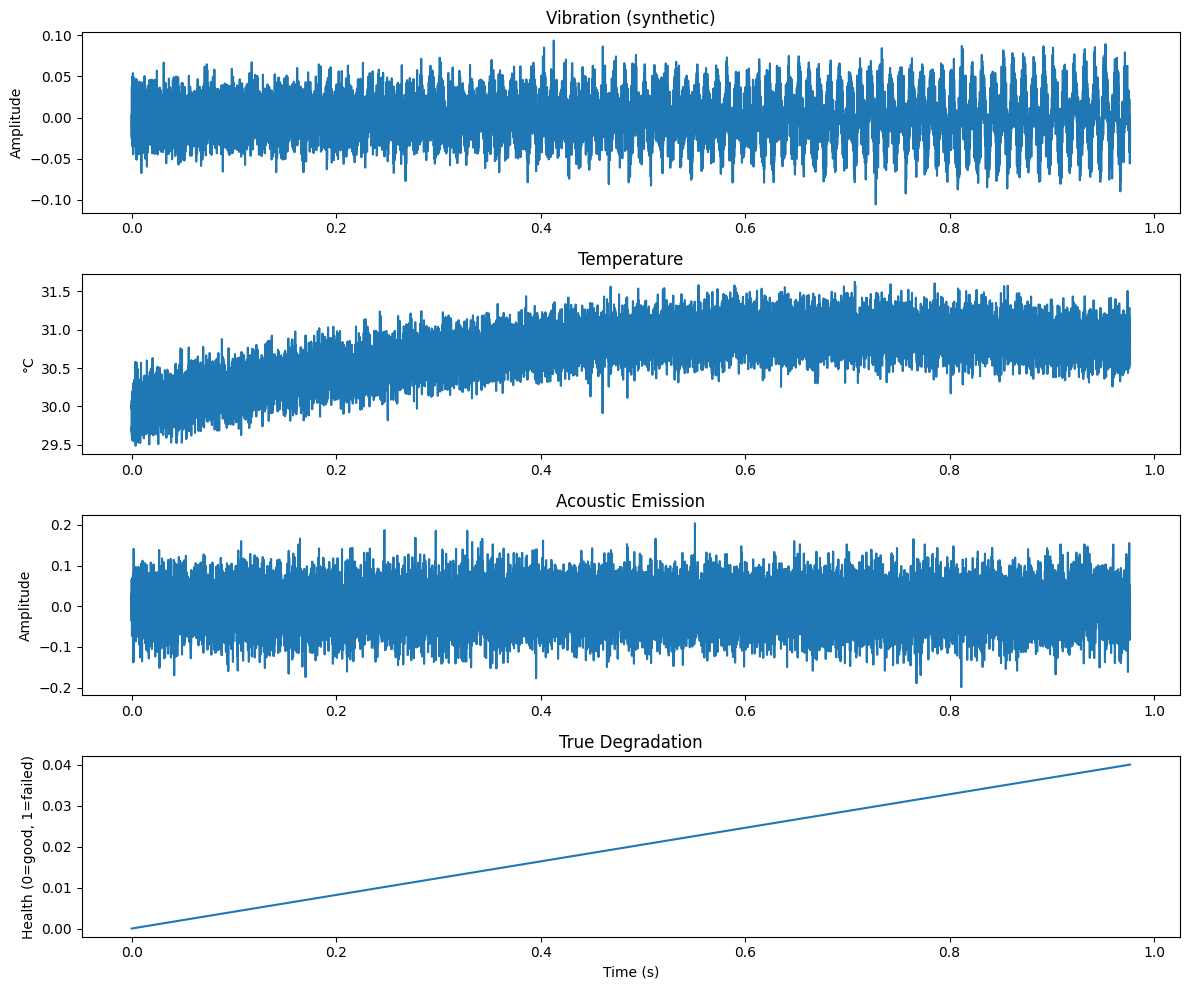

In [ ]:
# @title 4. Visualize a Snippet
plt.figure(figsize=(12, 10))

plt.subplot(4,1,1)
plt.plot(t[:20000], vibration[:20000])
plt.title("Vibration (synthetic)")
plt.ylabel("Amplitude")

plt.subplot(4,1,2)
plt.plot(t[:20000], temperature[:20000])
plt.title("Temperature")
plt.ylabel("°C")

plt.subplot(4,1,3)
plt.plot(t[:20000], acoustic[:20000])
plt.title("Acoustic Emission")
plt.ylabel("Amplitude")

plt.subplot(4,1,4)
plt.plot(t[:20000], degradation[:20000])
plt.title("True Degradation")
plt.ylabel("Health (0=good, 1=failed)")
plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import convolve

# Compute moving RMS of vibration (window 256)
window = 256
window_ones = np.ones(window)/window
vib_sq = vibration**2
vib_rms = np.sqrt(convolve(vib_sq, window_ones, mode='same'))

# Correlations with degradation
corr_vib_rms = np.corrcoef(vib_rms, degradation)[0,1]
corr_temp = np.corrcoef(temperature, degradation)[0,1]
corr_aco = np.corrcoef(acoustic, degradation)[0,1]

print(f"Correlation with degradation (using moving RMS for vibration):")
print(f"  Vibration RMS: {corr_vib_rms:.4f}")
print(f"  Temperature: {corr_temp:.4f}")
print(f"  Acoustic: {corr_aco:.4f}")

Correlation with degradation (using moving RMS for vibration):
  Vibration RMS: 0.9958
  Temperature: 0.9975
  Acoustic: 0.9198


In [ ]:
# @title 6. Save a Small Test Set (100k samples) for Quick Runs
small_idx = slice(0, 100000)
np.savez_compressed(
    os.path.join(save_dir, "pure_synthetic_small.npz"),
    vibration=vibration[small_idx],
    temperature=temperature[small_idx],
    acoustic=acoustic[small_idx],
    degradation=degradation[small_idx],
    time=t[small_idx]
)
print("Small dataset (100k samples) saved for quick testing.")

Small dataset (100k samples) saved for quick testing.
